# a03 Example - Bayesian Optimization using AX over Townsend Function

# Install External Libraries for Optimizer Implementation

In [ ]:
!python -m pip install ax-platform

# Imports

In [ ]:
import pyscan as ps
import numpy as np
import matplotlib.pyplot as plt
# from pyscan.drivers.thorlabs import # mirror angle controller
from pyscan.drivers.thorlabs.thorlabsbsc203 import ThorlabsBSC203 # fiber z-stage
# from pyscan.drivers.thorlabs.thorlabspm16 import ThorlabsPM16()

from ax.api.client import Client
from ax.api.configs import RangeParameterConfig

## Setup devices

In [ ]:
devices = ps.ItemAttribute()

devices.mirror0_theta = ThorlabsBSC203()
devices.mirror0_phi = ThorlabsBSC203()
devices.mirror1_theta = ThorlabsBSC203()
devices.mirror1_phi = ThorlabsBSC203()
devices.fiber_z = ThorlabsBSC203()
# devices.laser_power = ThorlabsPM16()

## Define a measure function

In [ ]:
def get_voltage_data(expt):
    """
    Reads the voltage from v1 and v2. Also adds a calculated voltage response to optimize.
    """

    devices = expt.devices

    d = ps.ItemAttribute()

    d.mirror0_theta_readout = devices.mirror0_theta.get_position()
    d.mirror0_phi_readout = devices.mirror0_phi.get_position()
    d.mirror1_theta_readout = devices.mirror1_theta.get_position()
    d.mirror1_phi_readout = devices.mirror1_phi.get_position()
    d.fiber_z_readout = devices.fiber_z.get_position()

    # d.laser_power_readout = devices.laser_power.get_power()

    return d

# Define live plot

In [ ]:
# @ps.live_plot
# def plot_optim_live(expt, x0, xf, y0, yf):
#     global fig, ax, cb0, cb1
#     x, y = np.mgrid[x0:xf:.01, y0:yf:.01]
#     z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
#     z = z.reshape(x.shape)
#     opt_arg = np.unravel_index(np.argmax(z, axis=None), z.shape)
#     ax.set_xlim([x0, xf])
#     ax.set_ylim([y0, yf])
#     pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
#     scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
#                 cmap='viridis')
#     ax.scatter(x[opt_arg], y[opt_arg], marker='o', facecolors='none', color='r')
#     ax.set_box_aspect(1)
#     if cb0 is None and cb1 is None:
#         cb0 = fig.colorbar(scatter, label="optimizer step")
#         cb1 = fig.colorbar(pcm, label="voltage response")
#     else:
#         cb0.update_normal(scatter)
#     ax.legend(["optimizer decision process", "optimum"], loc='lower left', bbox_to_anchor=(.1, -.35))
#     ax.set_xlabel("v1_readout")
#     ax.set_ylabel("v2_readout")
#     ax.set_title("Optimization of Voltage Response")

# Define runinfo

In [5]:
runinfo = ps.RunInfo()
runinfo.measure_function = get_voltage_data

# Implement `AbstractOptimizeScan` with `AXOptimizeScan`

In [ ]:
class AXOptimizeScan(ps.AbstractOptimizeScan):
    """
    AX Client API
    """


    def __init__(self, initialization_dict, prop, optimizer_inputs, sample_function_output,
                 bounds_list,
                 initialization_scans=None,
                 dt=0., n_max=100,
                 global_improvement_threshold=1e-2,
                 global_improvement_index_window=10,
                 global_improvement_start_index=10,
                 extremum='min'):
        
        super().__init__(initialization_dict, prop, optimizer_inputs, sample_function_output,
                         dt=dt, n_max=n_max)

        self.init_scans = initialization_scans
        if self.init_scans is not None: # additional non-optimized init pts after init_dict
            self.init_scan_ct = len(self.init_scans) # idx to expt 1 after len for init_dict
            self.complete_last_init_idx = self.init_scan_ct + 1 # 2 after len to complete last
        else:
            self.init_scan_ct = None
            self.complete_last_init_idx = None
        self.last_optim_idx = n_max - 1
        self.gi_t = global_improvement_threshold
        self.gi_i_w = global_improvement_index_window
        self.gi_st_i = global_improvement_start_index
        self.extremum = extremum
        parameters = [
            RangeParameterConfig(name=self.opt_in[i], parameter_type="float", bounds=bounds_list[i])
            for i in range(len(self.opt_in))
        ]
        self.client = Client()
        self.client.configure_experiment(parameters=parameters)
        match extremum:
            case 'max':
                self.objective = f"{self.sample_f_out}"
            case 'min':
                self.objective = f"-{self.sample_f_out}"
            case _:
                raise ValueError('Extremum must be max or min')
        self.client.configure_optimization(objective=self.objective)

        self.proposed_trial_index = None
        self.gi_latest_i = None

    def step_optimizer(self, index, experiment):
            
            def early_stop(f_out, f_out_best, index):
                es = False
                gi_d = f_out - f_out_best
                if self.extremum == 'min':
                    gi_d *= -1
                delta_over_threshold = gi_d > self.gi_t
                if delta_over_threshold:
                    self.gi_latest_i = index
                if self.gi_latest_i != None:
                    gi_i_d = index - self.gi_latest_i
                    index_delta_out_window = gi_i_d >= self.gi_i_w
                    stop_checking_started = index >= self.gi_st_i
                    es = index_delta_out_window and stop_checking_started
                return es

            i_prev = index - 1

            if index == 1 \
                or (self.init_scan_ct is not None \
                and index <= self.complete_last_init_idx):
                # load init pts into Client
                parameters = {
                    measurement: experiment.__dict__[measurement][i_prev]
                    for measurement in self.opt_in
                }
                prev_trial_index = self.client.attach_trial(parameters=parameters)
                f_out = experiment.__dict__[self.sample_f_out][i_prev]
                raw_data = {self.sample_f_out: f_out}
                self.client.complete_trial(trial_index=prev_trial_index, raw_data=raw_data)
            else:
                # load last proposed trial results into Client
                best_parameters, best_prediction, best_index, best_name \
                    = self.client.get_best_parameterization(use_model_predictions=False) # best before prev
                prev_trial_index = self.proposed_trial_index
                f_out = experiment.__dict__[self.sample_f_out][i_prev]
                raw_data = {self.sample_f_out: f_out}
                self.client.complete_trial(trial_index=prev_trial_index, raw_data=raw_data)
                f_out_best = best_prediction[self.sample_f_out][0] # get mean from (mean, sem) of output
                if index >= self.last_optim_idx or early_stop(f_out, f_out_best, index):
                    # if last optim: return best param and stop optim
                    f_in_next = [
                            best_parameters[measurement]
                            for measurement in self.opt_in
                        ]
                    self.running = False
                    print(f"best param: {best_parameters}")
                    return f_in_next

            if self.init_scan_ct is not None \
                and index <= self.init_scan_ct:
                # get next point from init_scans
                f_in_next = self.init_scans[i_prev] # init_scans idx 1 behind expt for init_dict
                return f_in_next
            else:
                # get next point from Client
                trials = self.client.get_next_trials(max_trials=1) # only 1 trial
                for trial_index, parameters in trials.items(): # only 1 item
                    f_in_next = [
                        parameters[measurement]
                        for measurement in self.opt_in
                    ]
                    self.proposed_trial_index = trial_index
                return f_in_next


# Instantiate OptimizeScan

In [7]:
x0 = -2.5
xf = 2.5
y0 = -1.5
yf = 1.5

In [8]:
runinfo.scan0 = AXOptimizeScan({'v1': 0., 'v2': 0.}, 'voltage', ('v1_readout', 'v2_readout'), 'vf',
                               ((x0, xf), (y0, yf)),
                               initialization_scans=[[1, 1], [1, -1], [-1, 1], [-1, -1]],
                               dt=1., n_max=100,
                               global_improvement_threshold=1e-2,
                               global_improvement_index_window=20,
                               global_improvement_start_index=50,
                               extremum='max')

# Run Experiments

In [ ]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

[INFO 01-12 18:50:38] ax.api.client: Trial 0 marked COMPLETED.
[INFO 01-12 18:50:40] ax.api.client: Trial 1 marked COMPLETED.
[INFO 01-12 18:50:41] ax.api.client: Trial 2 marked COMPLETED.
[INFO 01-12 18:50:42] ax.api.client: Trial 3 marked COMPLETED.
[INFO 01-12 18:50:43] ax.api.client: Trial 4 marked COMPLETED.
[INFO 01-12 18:50:43] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(node_name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(node_name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[WARNING 01-12 18:50:43] ax.generation_strategy.generation_node: gen failed with error GenerationStrategy exceeded `MAX_GEN_ATTEMPTS` of 5 while trying to 

best param: {'v1_readout': 1.9212798636015878, 'v2_readout': -0.9164412275856197}
Stopping Experiment


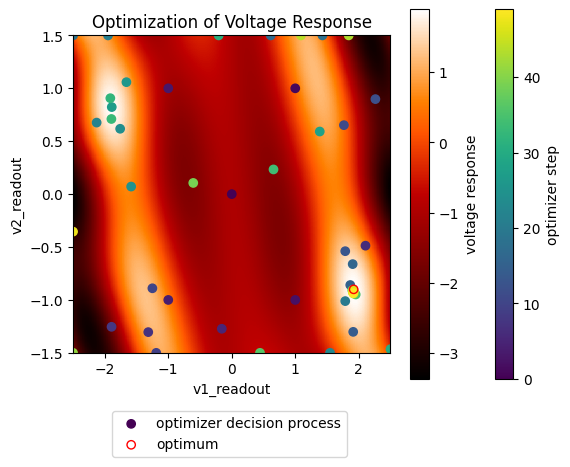

In [ ]:
# fig, ax = plt.subplots()
# cb0 = cb1 = None
# try:
#     plot_optim_live(expt, x0, xf, y0, yf)
# except KeyboardInterrupt:
#     expt.stop()

In [11]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x20f5bf72870>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x20f1e3bc8c0>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 37112)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.]),
 'v1_readout': array([ 0.        ,  1.        ,  1.        , -1.        , -1.        ,
        -0.15712455,  2.10632771, -1.31535154, -1.89332775, -1.18970046,
        -1.25018995,  1.76648618,  2.26249892,  1.78732559,  1.91273609,
         1.86636041,  1.90466681,  0.61359419,  1.42815659, -2.5       ,
         1.78742319, -1.94878752, -2.12852639,  1.54786572, -1.75797988,
        -1.58480127, -1.6592673 , -1.89005216,  1.38605216,  1.91410188,
         2.5       , -0.2063524 , -1.91

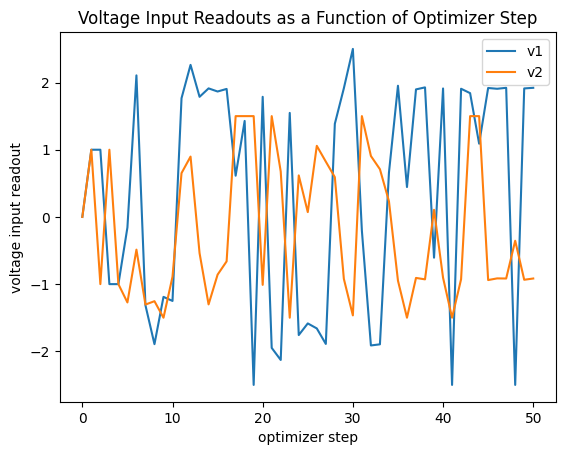

In [12]:
plt.plot(list(zip(expt.v1_readout, expt.v2_readout)))
plt.legend(['v1', 'v2'])
plt.xlabel("optimizer step")
plt.ylabel("voltage input readout")
plt.title("Voltage Input Readouts as a Function of Optimizer Step");

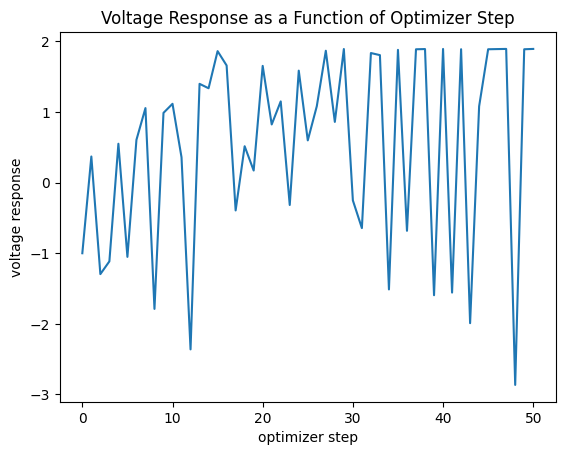

In [13]:
plt.plot(expt.vf)
plt.xlabel("optimizer step")
plt.ylabel("voltage response")
plt.title("Voltage Response as a Function of Optimizer Step");

In [ ]:
# def plot_optim_pcm(x0, xf, y0, yf):
#     fig, ax = plt.subplots()
#     x, y = np.mgrid[x0:xf:.01, y0:yf:.01]
#     z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
#     z = z.reshape(x.shape)
#     opt_arg = np.unravel_index(np.argmax(z, axis=None), z.shape)
#     ax.set_xlim([x0, xf])
#     ax.set_ylim([y0, yf])
#     pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
#     scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
#                          cmap='viridis')
#     ax.scatter(x[opt_arg], y[opt_arg], marker='o', facecolors='none', color='r')
#     ax.set_box_aspect(1)
#     fig.colorbar(scatter, label="optimizer step")
#     fig.colorbar(pcm, label="voltage response")
#     ax.legend(["optimizer decision process", "optimum"], loc='lower left', bbox_to_anchor=(.1, -.35))
#     ax.set_xlabel("v1_readout")
#     ax.set_ylabel("v2_readout")
#     ax.set_title("Optimization of Voltage Response")

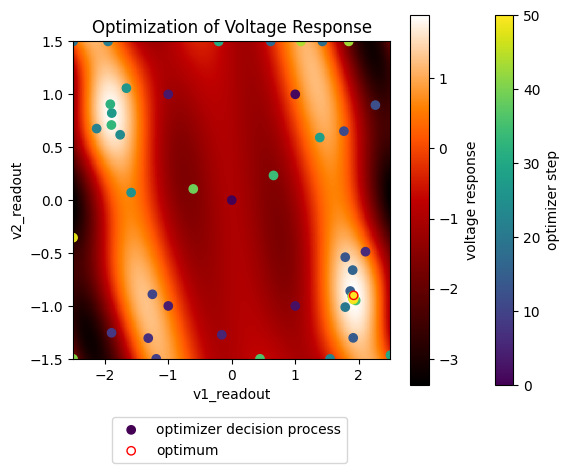

In [ ]:
# plot_optim_pcm(x0, xf, y0, yf)